In [1]:
import os 
os.chdir('/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2')
import torch
import numpy as np
from roentgenv2.train_code.validation_metrics import (
    TextPromptAlignmentMetrics,
    RealSyntheticSimilarityMetrics,
    IntraPromptDiversityMetrics,
    ValidationMetricsRunner
)

def test_similarity_metrics():
    """Test real-synthetic similarity metrics."""
    print("\n" + "="*60)
    print("Testing Real-Synthetic Similarity Metrics")
    print("="*60)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    metrics = RealSyntheticSimilarityMetrics(device=device)

    # Create dummy data
    batch_size = 10
    real_images = torch.randn(batch_size, 1, 512, 512).to(device)
    synthetic_images = torch.randn(batch_size, 1, 512, 512).to(device)

    print("\n1. Testing FID computation...")
    try:
        fid = metrics.compute_fid(real_images, synthetic_images, batch_size=5)
        print("   ✅ FID computed successfully")
        print(f"   FID Score: {fid:.2f}")
    except Exception as e:
        print(f"   ❌ Error: {e}")

    print("\n2. Testing MS-SSIM computation...")
    try:
        ms_ssim = metrics.compute_ms_ssim(real_images, synthetic_images)
        print("   ✅ MS-SSIM computed successfully")
        print(f"   MS-SSIM: {ms_ssim:.4f}")
    except Exception as e:
        print(f"   ❌ Error: {e}")

    print("\n3. Testing BioViL similarity computation...")
    try:
        biovil_sim = metrics.compute_biovil_similarity(real_images, synthetic_images)
        if np.isnan(biovil_sim):
            print("   ⚠️  BioViL model not available (optional)")
        else:
            print("   ✅ BioViL similarity computed successfully")
            print(f"   BioViL Similarity: {biovil_sim:.4f}")
    except Exception as e:
        print(f"   ⚠️  BioViL error (optional): {e}")

/home/vito/ibrahimm/.conda/envs/roentgen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

device = "cuda" if torch.cuda.is_available() else "cpu"
metrics = RealSyntheticSimilarityMetrics(device=device)

# Create dummy data
batch_size = 10
real_images = torch.randn(batch_size, 1, 512, 512).to(device)
synthetic_images = torch.randn(batch_size, 1, 512, 512).to(device)

biovil_sim = metrics.compute_biovil_similarity(real_images, synthetic_images)


RuntimeError: All methods failed to extract BioViL embeddings:
  - Method 2 (image processor) skipped: processor not available
  - Method 3 (direct vision model) skipped: no vision encoder found

The BiomedVLP-CXR-BERT-specialized model may require special handling. Consider using an alternative model or disabling BioViL metrics by catching this error.

In [3]:
"""
Extract BioViL embeddings from images.

Args:
    images: Images [N, C, H, W]

Returns:
    Embeddings [N, D]
"""
from PIL import Image
images = real_images
# Normalize to [0, 1]
if images.min() < 0:
    images = (images + 1.0) / 2.0

# Convert to CPU numpy for PIL conversion if needed
images_np = images.cpu().numpy()

# BioViL expects RGB images
if images.shape[1] == 1:
    images_np = images_np.repeat(3, axis=1)

errors_encountered = []



In [1]:

from transformers import AutoModel, AutoTokenizer

# Load the full model
model = AutoModel.from_pretrained(
    "microsoft/BiomedVLP-CXR-BERT-specialized",
    trust_remote_code=True
)
tokenizer = AutoTokenizer.from_pretrained(
    "microsoft/BiomedVLP-CXR-BERT-specialized",
    trust_remote_code=True
)

/home/vito/ibrahimm/.conda/envs/roentgen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model.get_image_features

AttributeError: 'CXRBertModel' object has no attribute 'get_image_features'

In [9]:
from transformers import AutoProcessor, AutoModel
from PIL import Image
import torch

# 1. Load the model and processor
model_name = "microsoft/BiomedVLP-CXR-BERT-specialized"
processor = AutoProcessor.from_pretrained(model_name, trust_remote_code=True)
model = AutoModel.from_pretrained(model_name, trust_remote_code=True)

# 2. Load your image
import numpy as np
from PIL import Image

# Generate a random RGB image (e.g., 224x224)
random_array = np.random.randint(0, 256, (224, 224, 3), dtype=np.uint8)
image = Image.fromarray(random_array, 'RGB')

# 3. Preprocess the image for the model
inputs = processor(images=[image], return_tensors="pt")

# 4. Get the image embeddings (from the image encoder)
with torch.no_grad():
    embeddings = model.get_image_features(**inputs)

# 5. Normalize the embeddings (optional, useful for similarity search)
embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=-1)

print(embeddings.shape)  # typically [1, hidden_dim]


ValueError: You need to specify either `text` or `text_target`.

In [23]:
# install the library (if not already)
# pip install hi-ml-multimodal

import torch
from PIL import Image
from health_multimodal.image.utils import get_image_inference, ImageModelType

# Choose model type
image_inference_engine = get_image_inference(image_model_type=ImageModelType.BIOVIL)
transform = image_inference_engine.transform  # preprocessing pipeline (resize, normalize, etc.)



# Generate a random grayscale image (e.g., 224x224)
random_array = np.random.randint(0, 256, (224, 224), dtype=np.uint8)
image = Image.fromarray(random_array, 'L')
images = [image, image]
# The engine wraps both transform and model
batch = torch.stack([transform(p) for p in images])

# Extract embedding
with torch.no_grad():
    output = image_inference_engine.model(batch)   # returns ImageModelOutput
    embedding = output.projected_global_embedding          # shape [1, joint_feature_size]

# (Optional) Normalize
embedding = torch.nn.functional.normalize(embedding, p=2, dim=-1)

print(embedding.shape)  # e.g. [1, 128]


torch.Size([2, 128])


In [20]:
image_inference_engine.model

ImageModel(
  (encoder): ImageEncoder(
    (encoder): ResNetHIML(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): R

The ground-truth bounding box annotation for the phrase *Left basilar consolidation seen* is shown in the middle figure (in black).

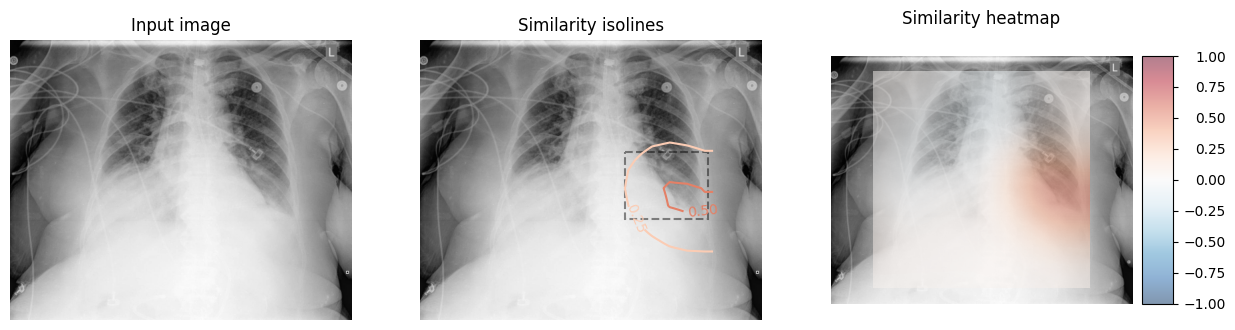

In [14]:
image_url = "https://openi.nlm.nih.gov/imgs/512/242/1445/CXR1445_IM-0287-4004.png"
text_prompt = "Left basilar consolidation seen"
# Ground-truth bounding box annotation(s) for the input text prompt
bboxes = [
    (306, 168, 124, 101),
]

text = (
    'The ground-truth bounding box annotation for the phrase'
    f' *{text_prompt}* is shown in the middle figure (in black).'
)

display(Markdown(text))
plot_phrase_grounding_from_url(image_url, text_prompt, bboxes)

In [14]:
import sys
from pathlib import Path
import os 
# Add project root to Python path
project_root = '/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/roentgenv2/train_code'
sys.path.insert(0, str(project_root))
from models import load_models, EMAModel, load_hcn

from dataset_wds import RGFineTuningWebDataset, RGFineTuningImageDirectoryDataset
data_filter_file = None
use_hcn = False

(
    text_encoder,
    tokenizer,
    vae,
    unet,
    noise_scheduler,
    text_encoder_name,
    freeze_pooler,
    unet_config_changed,
    unet_config,
    kwargs_from_pretrained,
) = load_models(args, accelerator, logger)


url_root = "/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/training_data"
url_list = [
    os.path.join(url_root, x)
    for x in os.listdir(url_root)
    if x.endswith(".tar")
]

train_dataset = RGFineTuningWebDataset(
    url_list=url_list,
    tokenizer=tokenizer,
    data_filter_file=data_filter_file,
    use_hcn=use_hcn,
)
train_batch_size = 4
train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=train_batch_size,
)

print(f"dataset len {len(train_dataset)}")
print(f"dataloader len {len(train_dataloader)}")

/home/vito/ibrahimm/.conda/envs/roentgen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'args' is not defined